In [1]:
import numpy as np
import pandas as pd

In [2]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("folder/Match_dataset_clean.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [3]:
from Data.data_preparing import DataPreparer

preparer = DataPreparer(match_data_filepath="folder/Match_dataset_clean.csv",
                        market_value_filepath="Data/ligue1_market_values_2010_2025.csv")

df = preparer.merge_df(save=True)

Processing complete. Saving merged dataframe to 'merged_df.csv'.


In [5]:
from Data.data_processing import DataProcesser

processer = DataProcesser("merged_df.csv")

processer.remove_year("25-26")

train_df, test_df = processer.split_train_test(test_size=306)

train_data, test_data = processer.get_train_test_data()

Tolerance threshold attained after 234 iterations
Model fitted successfully !
Tolerance threshold attained after 236 iterations
Model fitted successfully !
Tolerance threshold attained after 237 iterations
Model fitted successfully !
Tolerance threshold attained after 239 iterations
Model fitted successfully !
Tolerance threshold attained after 241 iterations
Model fitted successfully !
Tolerance threshold attained after 244 iterations
Model fitted successfully !
Tolerance threshold attained after 247 iterations
Model fitted successfully !
Tolerance threshold attained after 251 iterations
Model fitted successfully !
Tolerance threshold attained after 255 iterations
Model fitted successfully !
Tolerance threshold attained after 260 iterations
Model fitted successfully !
Tolerance threshold attained after 266 iterations
Model fitted successfully !
Tolerance threshold attained after 273 iterations
Model fitted successfully !
Tolerance threshold attained after 282 iterations
Model fitted s

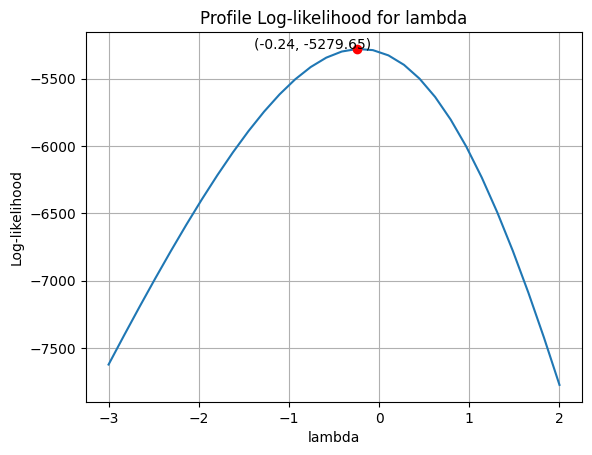

In [13]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

In [14]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [ ]:
# NBTR